###РАЗДЕЛ 1.2.1 — РИСУНОК 1 (Гистограммы распределения)

✅ Данные загружены: 49732 записей, 17 признаков
Типы данных:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Пропусков: 0
✅ Рисунок 1 сохранён: figure_1_histograms.png


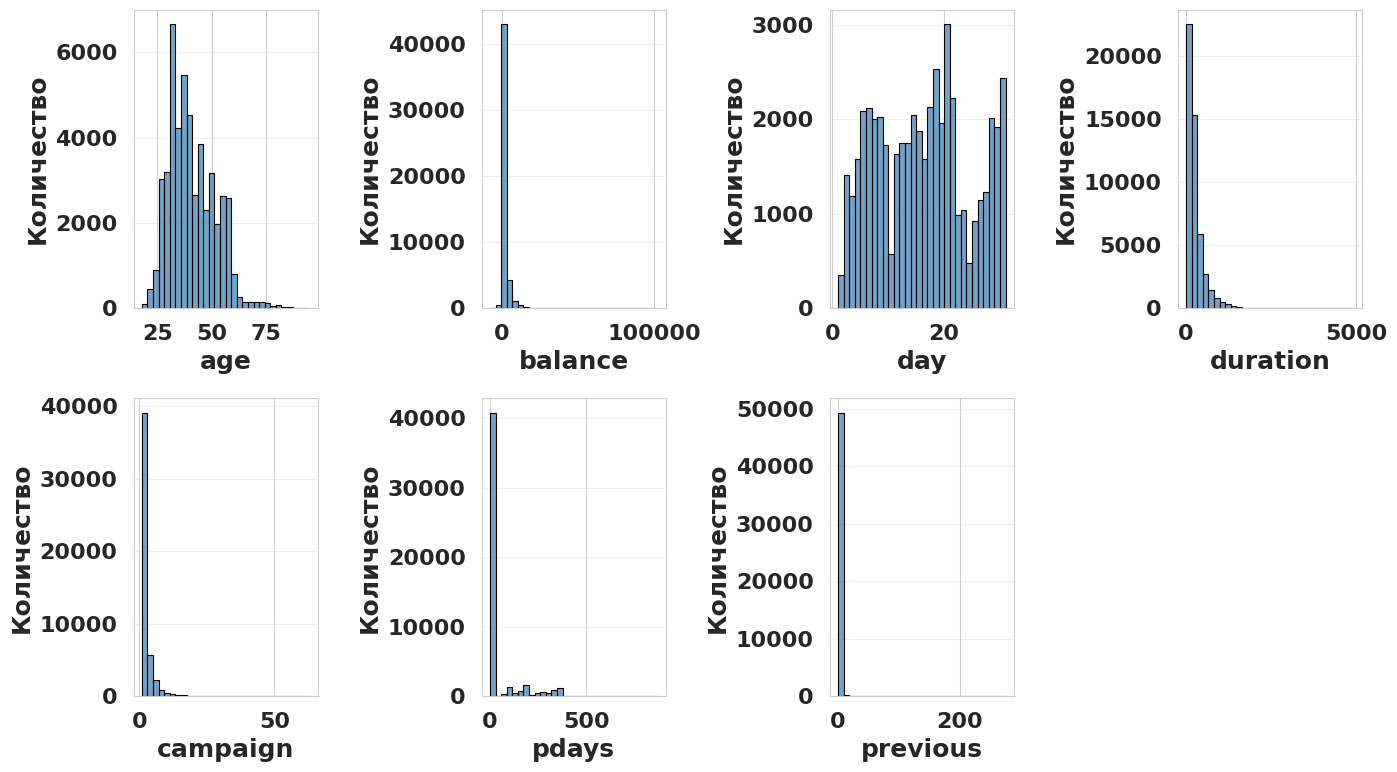

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set_style("whitegrid")

# === ГЛОБАЛЬНЫЕ НАСТРОЙКИ ШРИФТА (КРУПНЫЙ И ЧИТАЕМЫЙ) ===
plt.rcParams.update({
    'font.size': 16,              # Основной шрифт
    'axes.titlesize': 18,         # Заголовки
    'axes.labelsize': 18,         # Подписи осей
    'xtick.labelsize': 16,        # Цифры по X
    'ytick.labelsize': 16,        # Цифры по Y
    'font.weight': 'bold'         # Жирный шрифт
})

# === ЗАГРУЗКА ДАННЫХ (если ещё не загружены) ===
# Если df уже есть в памяти — этот блок можно пропустить
try:
    train = pd.read_csv('/content/drive/MyDrive/Dataset/train.csv', sep=';')
    test = pd.read_csv('/content/drive/MyDrive/Dataset/test.csv', sep=';')
    df = pd.concat([train, test], ignore_index=True)
    print(f"✅ Данные загружены: {df.shape[0]} записей, {df.shape[1]} признаков")
except:
    print("ℹ️ Используйте уже загруженный df")

# === ПРОВЕРКА ТИПОВ И ПРОПУСКОВ ===
print("="*60)
print("Типы данных:")
print(df.dtypes)
print(f"\nПропусков: {df.isnull().sum().sum()}")

# === ВЫБОР ЧИСЛОВЫХ КОЛОНОК ===
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# === СОЗДАНИЕ ФИГУРЫ ===
fig = plt.figure(figsize=(14, 8))

# === ПОСТРОЕНИЕ ГИСТОГРАММ ===
for i, col in enumerate(numerical_cols):
    ax = fig.add_subplot(2, 4, i+1)

    # Гистограмма
    sns.histplot(df[col], bins=30, color='steelblue', edgecolor='black', linewidth=0.8, ax=ax)

    # === ПОДПИСИ: ТОЛЬКО СНИЗУ, БЕЗ ДУБЛИРОВАНИЯ ===
    ax.set_xlabel(col, fontsize=18, fontweight='bold')      # Название признака (только снизу)
    ax.set_ylabel('Количество', fontsize=18, fontweight='bold')  # Ось Y
    ax.tick_params(labelsize=16, pad=8)                     # Крупные цифры на осях

    ax.grid(True, alpha=0.3, axis='y')

# === УДАЛЕНИЕ ПУСТОЙ 8-й ЯЧЕЙКИ ===
fig.delaxes(fig.add_subplot(2, 4, 8))


# === СОХРАНЕНИЕ И ОТОБРАЖЕНИЕ ===
plt.tight_layout()
plt.savefig('figure_1_histograms.png', dpi=150, bbox_inches='tight', facecolor='white')
print("✅ Рисунок 1 сохранён: figure_1_histograms.png")
plt.show()

###РАЗДЕЛ 1.2.2 — РИСУНОК 2 (Парные зависимости seaborn)

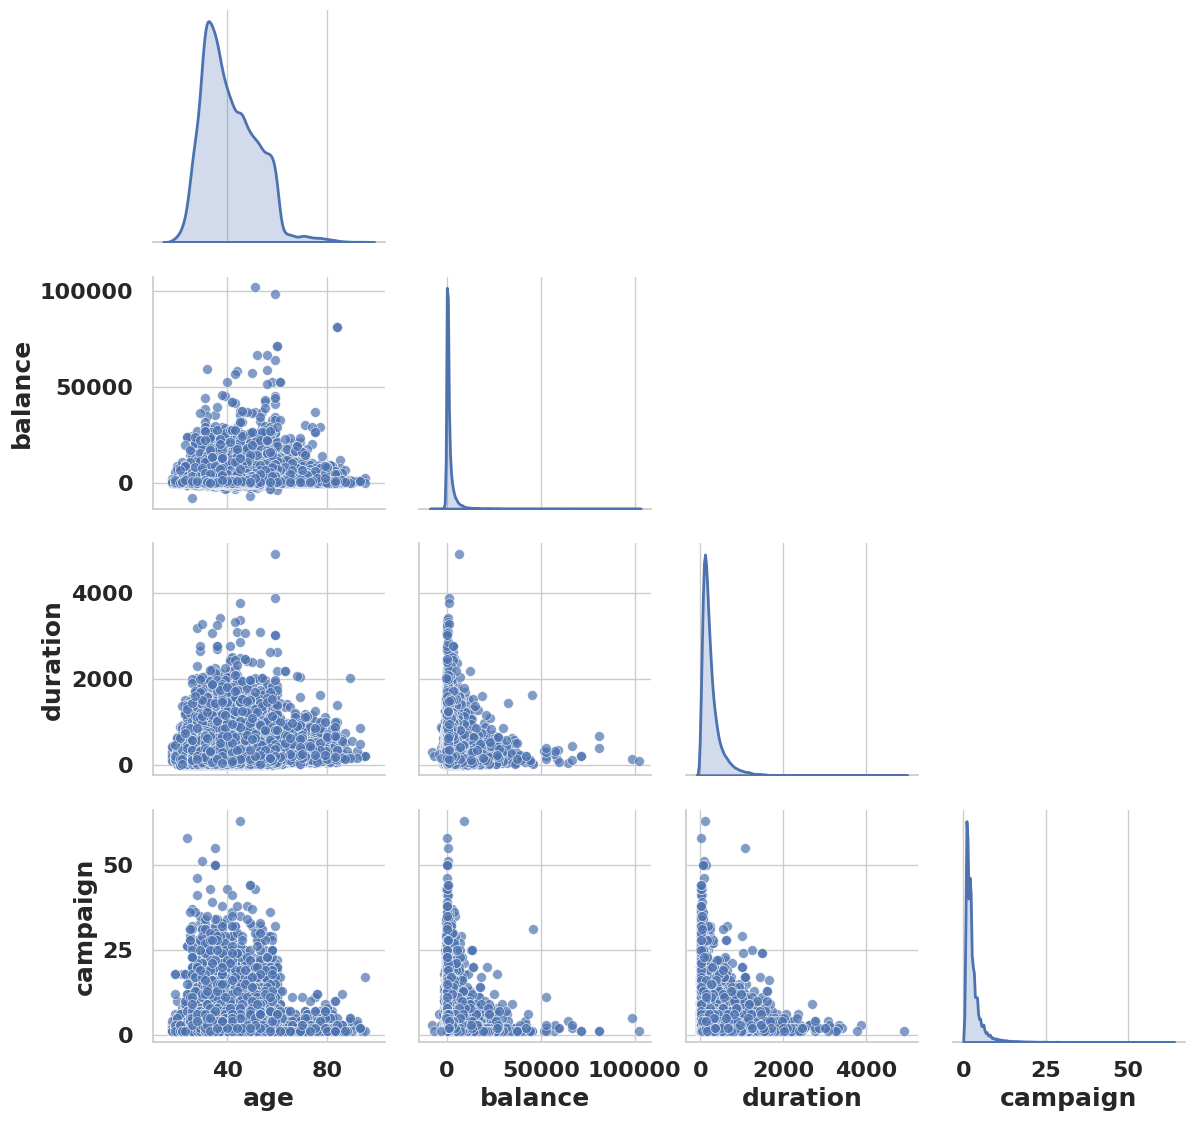

In [2]:
# ============================================================================
# 1.2.2 РИСУНОК 2: Парные зависимости (seaborn pairplot)
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.3)

pair_cols = ['age', 'balance', 'duration', 'campaign']

g = sns.pairplot(
    df[pair_cols],
    corner=True,
    diag_kind='kde',
    height=3.0,
    aspect=1.0,
    plot_kws={'alpha': 0.7, 's': 50, 'edgecolor': 'white', 'linewidth': 0.5},
    diag_kws={'fill': True, 'linewidth': 2}
)


for ax in g.axes.flat:
    if ax is not None:
        ax.tick_params(axis='both', which='major', labelsize=16, pad=8)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(3, integer=True))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(3, integer=True))
        ax.set_xlabel(ax.get_xlabel(), fontsize=18, fontweight='bold')
        ax.set_ylabel(ax.get_ylabel(), fontsize=18, fontweight='bold')

g.fig.subplots_adjust(wspace=0.15, hspace=0.15, left=0.12, right=0.98, top=0.98, bottom=0.12)
plt.savefig('figure_2.png', dpi=150, bbox_inches='tight', pad_inches=0.3)
plt.show()


###1.2.3 РИСУНОК 3: Интерактивный scatter plot (Plotly)

In [3]:
import plotly.express as px

fig = px.scatter(
    df,
    x='age',
    y='duration',
    color='y',
    color_discrete_map={'yes': '#e74c3c', 'no': '#3498db'},
    opacity=0.85,
    labels={
        'age': 'Возраст (лет)',
        'duration': 'Длительность контакта (сек)',
        'y': 'Подписка на депозит'
    },

    width=950,
    height=650
)

fig.update_traces(marker=dict(size=9, line=dict(width=1, color='DarkSlateGray')))

fig.update_layout(
    font=dict(size=20, family="Arial, sans-serif", color="#000000"),
    title_font=dict(size=26, family="Arial, sans-serif", color="#000000"),
    xaxis_title_font=dict(size=22, family="Arial, sans-serif"),
    yaxis_title_font=dict(size=22, family="Arial, sans-serif"),
    xaxis=dict(tickfont=dict(size=20), ticklen=8, tickwidth=2, tickcolor='black', gridcolor='lightgray'),
    yaxis=dict(tickfont=dict(size=20), ticklen=8, tickwidth=2, tickcolor='black', gridcolor='lightgray'),
    legend=dict(font=dict(size=20), title_font=dict(size=20), x=0.98, y=0.98, xanchor='right', yanchor='top', bgcolor='rgba(255, 255, 255, 0.95)'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=70, r=50, t=90, b=70)
)

fig.show()


###1.2.5 РИСУНОК 4: Тепловая карта пропусков

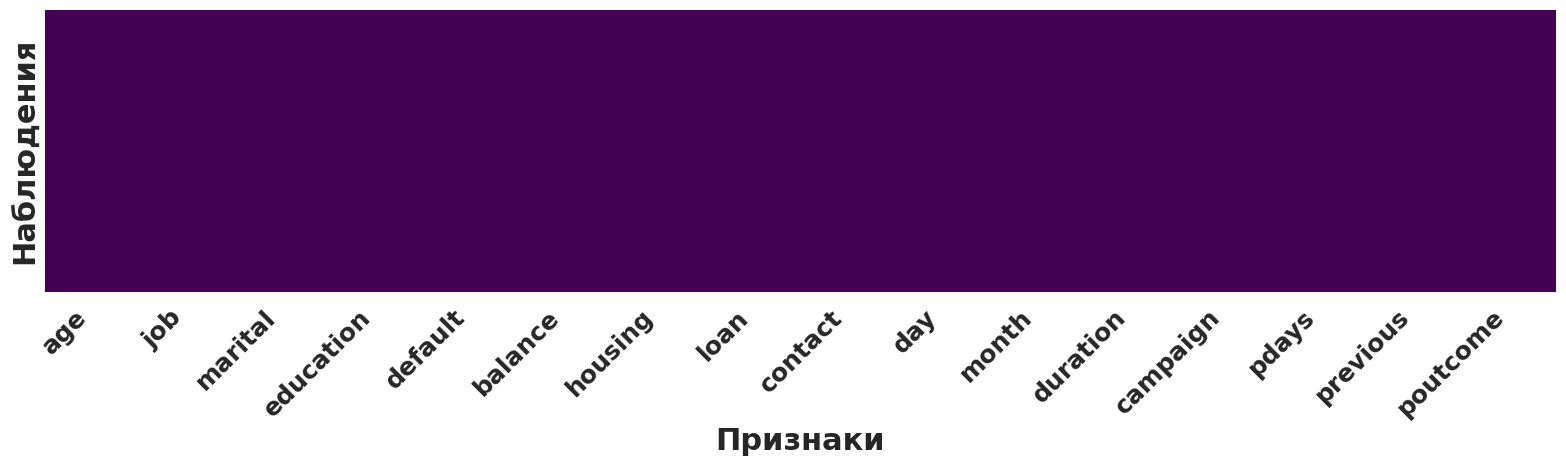

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Глобальные настройки шрифтов (увеличены для чёткости в Word)
plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 22,
    'axes.titlesize': 24,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'font.weight': 'bold'
})

# Увеличиваем размер фигуры для лучшего размещения крупного текста
fig = plt.figure(figsize=(16, 5))

# Строим тепловую карту (исключаем таргет 'y' как договорились)
sns.heatmap(df.drop('y', axis=1).isnull(),
            cbar=False,
            cmap='viridis',
            yticklabels=False)

# Подписи осей и заголовок
plt.xlabel('Признаки', fontsize=22, fontweight='bold')
plt.ylabel('Наблюдения', fontsize=22, fontweight='bold')
plt.xticks(fontsize=18, rotation=45, ha='right')


# Сохранение с высоким качеством
plt.tight_layout()
plt.savefig('figure_4_clean.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


###1.2.5 РИСУНОК 5: Матрица корреляций Пирсона

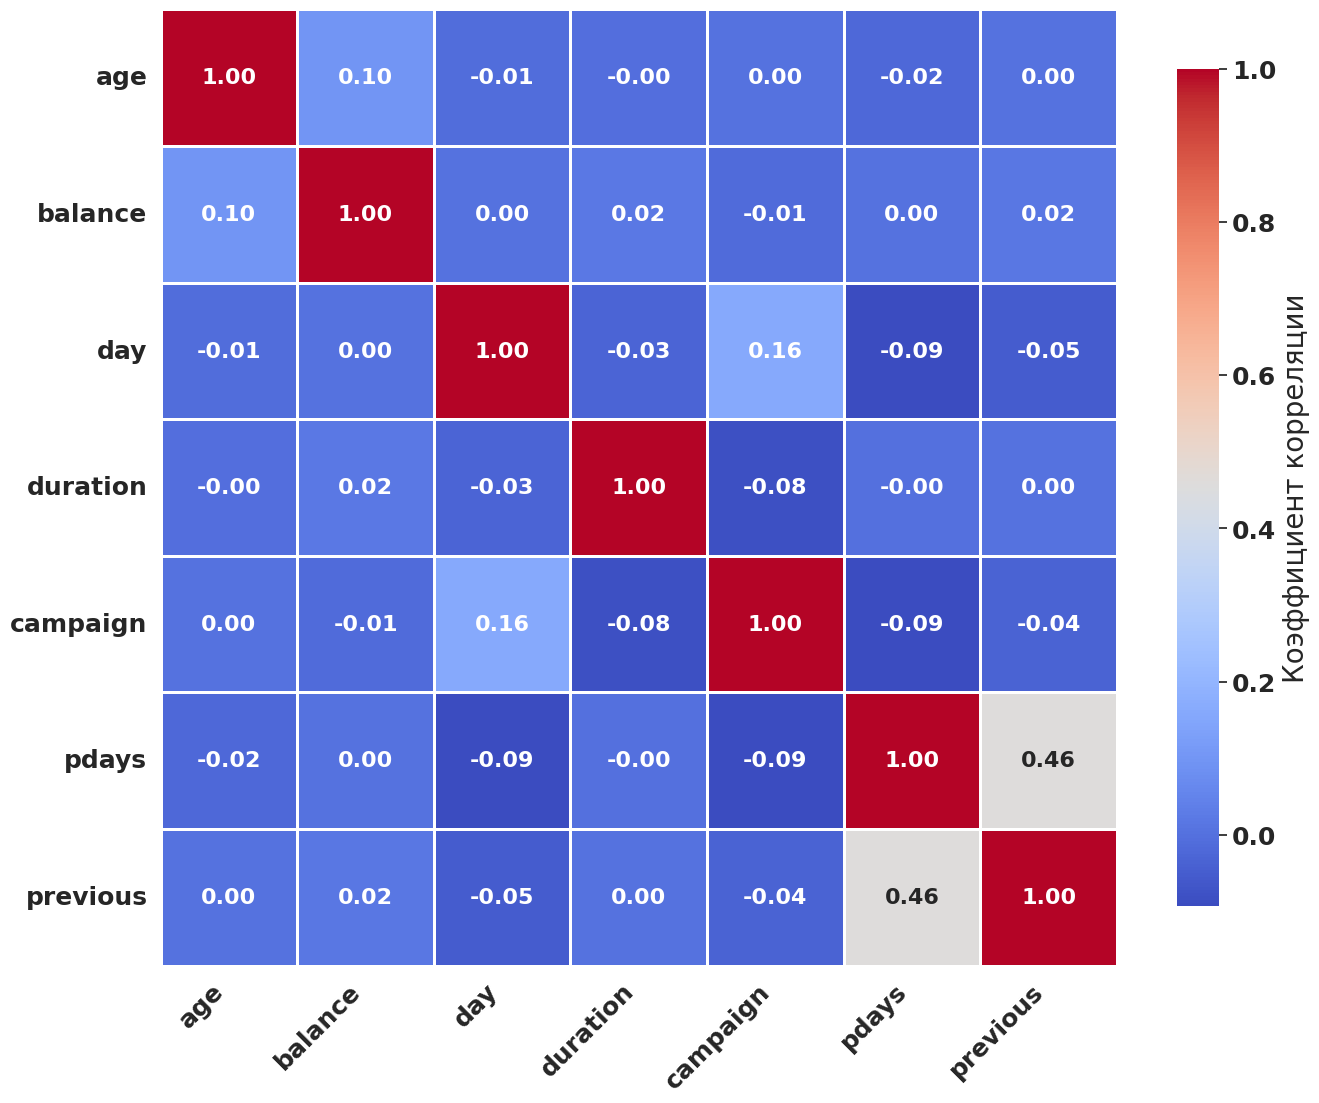

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Глобальные настройки крупного шрифта
plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 20,
    'axes.titlesize': 24,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'font.weight': 'bold'
})

# Увеличиваем размер фигуры для размещения крупного текста
plt.figure(figsize=(14, 12))

# Построение тепловой карты
corr_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    annot_kws={'size': 16, 'weight': 'bold'},  # УВЕЛИЧЕН шрифт значений внутри ячеек
    square=True,
    linewidths=1,
    cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'}
)
plt.xticks(fontsize=18, rotation=45, ha='right', fontweight='bold')  # Подписи X
plt.yticks(fontsize=18, fontweight='bold', rotation=0)  # Подписи Y

# Сохранение с высоким качеством
plt.tight_layout()
plt.savefig('figure_5_clean.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


###1.2.6 Устранение дубликатов строк

In [6]:
# Загружаем файлы ОТДЕЛЬНО
train = pd.read_csv('/content/drive/MyDrive/Dataset/train.csv', sep=';')
test = pd.read_csv('/content/drive/MyDrive/Dataset/test.csv', sep=';')

print(" Дубликаты в train.csv:", train.duplicated().sum())
print(" Дубликаты в test.csv:", test.duplicated().sum())

# Проверяем пересечения между train и test
combined = pd.concat([train, test], ignore_index=True)
duplicates_total = combined.duplicated().sum()
print(f"📊 Всего дубликатов (включая пересечения): {duplicates_total}")

# Теперь объединяем и удаляем
df = combined.drop_duplicates().reset_index(drop=True)
print(f" Удалено дубликатов: {duplicates_total}")
print(f" Осталось записей: {len(df)}")

 Дубликаты в train.csv: 0
 Дубликаты в test.csv: 0
📊 Всего дубликатов (включая пересечения): 4521
 Удалено дубликатов: 4521
 Осталось записей: 45211


###1.2.7 РИСУНОК 6: Визуализация выбросов (Boxplot)

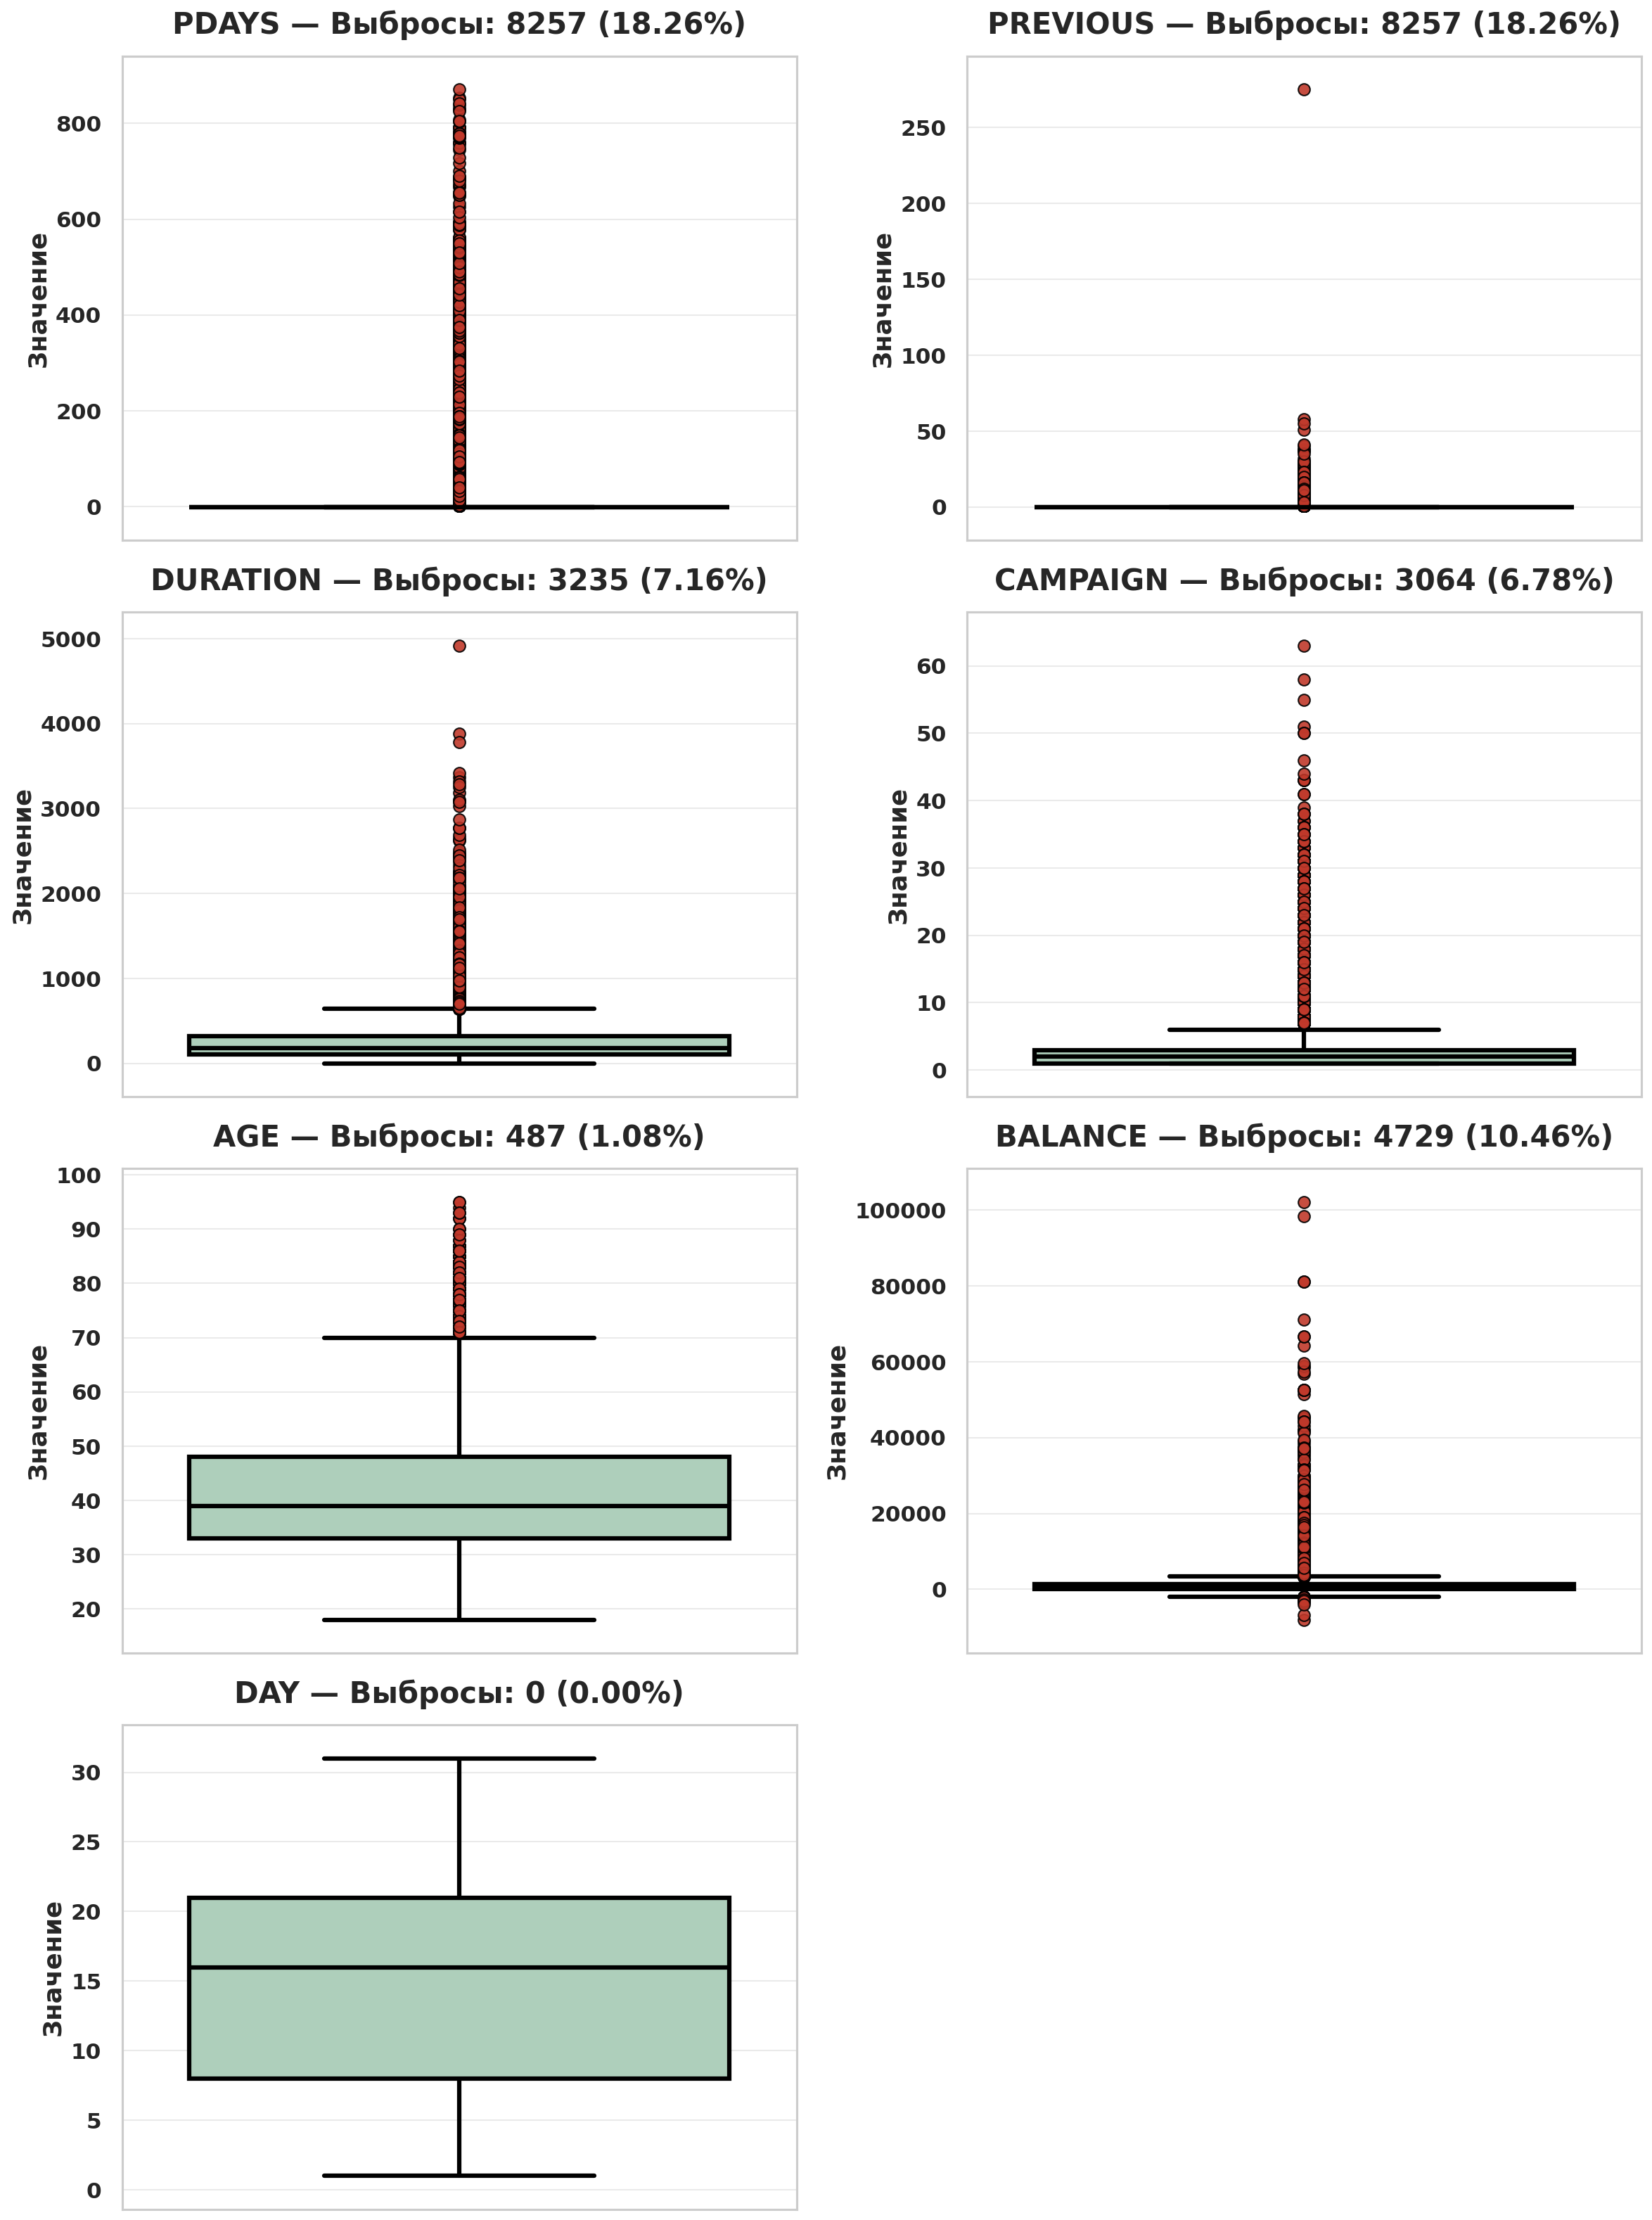

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# === ГЛОБАЛЬНЫЕ НАСТРОЙКИ ШРИФТА (МАКСИМАЛЬНО ЧИТАЕМЫЕ) ===
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'font.weight': 'bold',
    'figure.dpi': 150,
    'axes.linewidth': 1.5
})

features = ['pdays', 'previous', 'duration', 'campaign', 'age', 'balance', 'day']
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(features):
    # Расчёт статистики для заголовка
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    count = len(outliers)
    pct = (count / len(df)) * 100

    # Рисуем boxplot с ЖИРНЫМИ линиями для идеальной видимости
    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color='#a8d5ba',
        linewidth=3,
        boxprops=dict(linewidth=3, edgecolor='black'),
        medianprops=dict(linewidth=3, color='black'),
        whiskerprops=dict(linewidth=3, color='black'),
        capprops=dict(linewidth=3, color='black'),
        flierprops=dict(marker='o', markerfacecolor='#c0392b',
                        markersize=8, alpha=0.9, markeredgecolor='black')
    )

    # Оформление БЕЗ жёлтых плашек
    axes[i].set_title(f'{col.upper()} — Выбросы: {count} ({pct:.2f}%)',
                      fontsize=20, fontweight='bold', pad=15)
    axes[i].set_ylabel('Значение', fontsize=17, fontweight='bold')
    axes[i].tick_params(labelsize=15, pad=8, width=1.5)
    axes[i].grid(True, alpha=0.4, axis='y', linewidth=1)
    axes[i].set_axisbelow(True)
    axes[i].margins(y=0.08)  # Отступы, чтобы ящик не прилипал к краям

# Удаляем пустую ячейку
fig.delaxes(axes[7])

# Сохранение
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.savefig('figure_6_commission.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


###1.2.8 УСЛОВНАЯ ФИЛЬТРАЦИЯ СЭМПЛОВ

In [8]:
print("="*60)
print("1.2.8 Применение фильтров:")
print("="*60)

# 1) Фильтр: age > 30
df_age = df[df['age'] > 30]
print(f"1) Фильтр 'age > 30': {len(df_age)} строк")

# 2) Фильтр: balance > 0 & duration > 100
df_bal_dur = df[(df['balance'] > 0) & (df['duration'] > 100)]
print(f"2) Фильтр 'balance > 0 & duration > 100': {len(df_bal_dur)} строк")

# 3) Фильтр: campaign < 5 & pdays != -1
df_camp_pdays = df[(df['campaign'] < 5) & (df['pdays'] != -1)]
print(f"3) Фильтр 'campaign < 5 & pdays != -1': {len(df_camp_pdays)} строк")
# === РАСЧЁТ МЕДИАНЫ AGE ===
print("\n" + "="*60)
print("МЕДИАНА ВОЗРАСТА")
print("="*60)
median_before = df['age'].median()
median_after = df_age['age'].median()  # df_age уже есть из фильтра 1
print(f"Медиана age до фильтрации: {median_before}")
print(f"Медиана age после фильтрации (age > 30): {median_after}")
print(f"✅ Смещение медианы: {median_before} → {median_after}")

1.2.8 Применение фильтров:
1) Фильтр 'age > 30': 38181 строк
2) Фильтр 'balance > 0 & duration > 100': 28856 строк
3) Фильтр 'campaign < 5 & pdays != -1': 7629 строк

МЕДИАНА ВОЗРАСТА
Медиана age до фильтрации: 39.0
Медиана age после фильтрации (age > 30): 42.0
✅ Смещение медианы: 39.0 → 42.0


###1.2.9 ДОБАВЛЕНИЕ ШУМА

In [9]:
print("\n" + "="*60)
print("1.2.9 Добавление шума (Gaussian Noise):")
print("="*60)
import numpy as np

# Создаем копию, чтобы не портить исходные данные без необходимости
df_noise = df.copy()

# 1) age ~ N(0, 2) -> шум с мат. ожиданием 0 и дисперсией 2 (std=2)
np.random.seed(42) # Для воспроизводимости результата
age_noise = np.random.normal(0, 2, len(df_noise))
df_noise['age_noised'] = df_noise['age'] + age_noise
print(f"✅ Добавлен шум к age: N(0, 2). Пример: {df_noise['age'].iloc[0]} -> {df_noise['age_noised'].iloc[0]:.2f}")

# 2) balance ~ N(0, 0.05 * balance) -> пропорциональный шум
# (Стандартное отклонение зависит от значения баланса)
# Примечание: если баланс отрицательный, берем модуль для std, чтобы не было ошибки
balance_std = np.abs(df_noise['balance'] * 0.05)
balance_noise = np.random.normal(0, balance_std)
df_noise['balance_noised'] = df_noise['balance'] + balance_noise
print(f"✅ Добавлен шум к balance: N(0, 0.05*value). Пример: {df_noise['balance'].iloc[0]} -> {df_noise['balance_noised'].iloc[0]:.2f}")


1.2.9 Добавление шума (Gaussian Noise):
✅ Добавлен шум к age: N(0, 2). Пример: 58 -> 58.99
✅ Добавлен шум к balance: N(0, 0.05*value). Пример: 2143 -> 2131.40


###1.2.10 ПРЕОБРАЗОВАНИЕ ЧИСЛОВЫХ ДАННЫХ В КАТЕГОРИАЛЬНЫЕ

In [10]:
print("\n" + "="*60)
print("1.2.10 Преобразование age в категории:")
print("="*60)

# Используем функцию pd.cut для создания интервалов
bins = [18, 30, 45, 60, 100]
labels = ['18-30', '31-45', '46-60', '61+']

df_noise['age_group'] = pd.cut(df_noise['age_noised'], bins=bins, labels=labels, include_lowest=True)

print("✅ Категории созданы. Примеры значений:")
print(df_noise[['age_noised', 'age_group']].head(10))

# Посчитаем, сколько людей попало в каждую группу
print("\n📊 Распределение по возрастным когортам:")
print(df_noise['age_group'].value_counts().sort_index())


1.2.10 Преобразование age в категории:
✅ Категории созданы. Примеры значений:
   age_noised age_group
0   58.993428     46-60
1   43.723471     31-45
2   34.295377     31-45
3   50.046060     46-60
4   32.531693     31-45
5   34.531726     31-45
6   31.158426     31-45
7   43.534869     31-45
8   57.061051     46-60
9   44.085120     31-45

📊 Распределение по возрастным когортам:
age_group
18-30     6645
31-45    23456
46-60    13217
61+       1858
Name: count, dtype: int64


###1.2.12 Оценка изменения в данных после фильтрации (Рисунок 7)

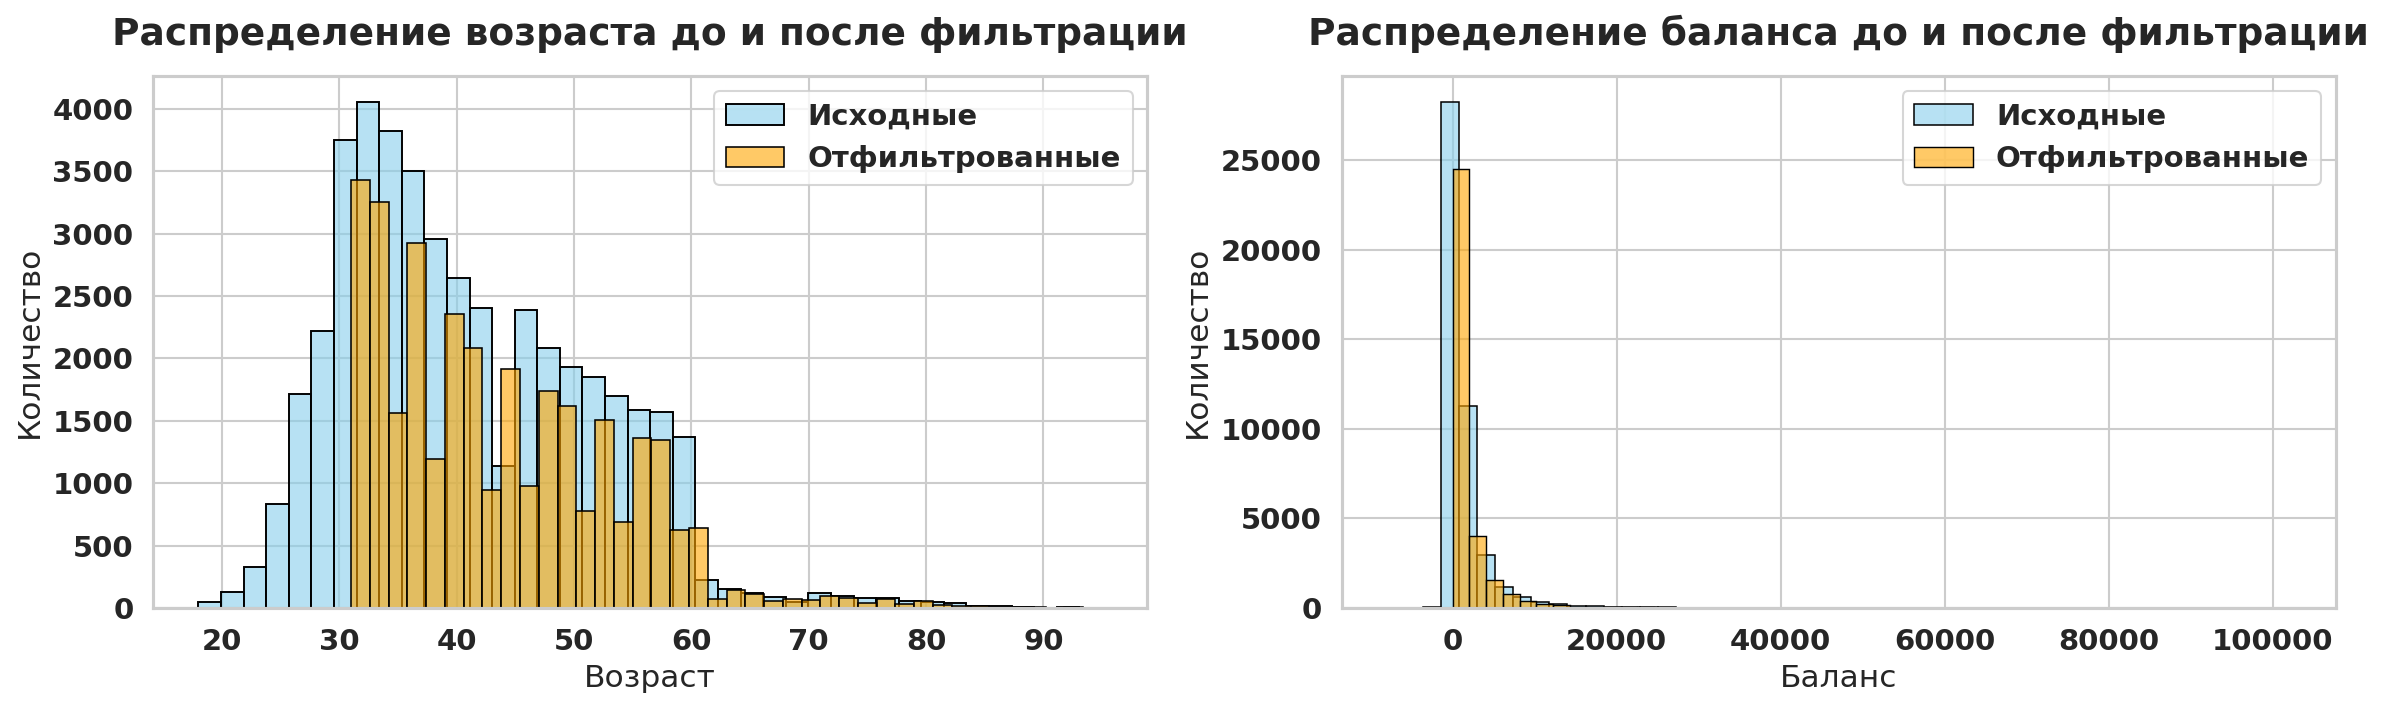

In [11]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'font.weight': 'bold'
})

# 1. Создаем отфильтрованную версию данных
# Используем логику из раздела 1.2.8 (age > 30 и balance > 0) для демонстрации
df_filtered = df[(df['age'] > 30) & (df['balance'] > 0)]

# 2. Создаем фигуру (2 графика в ряд)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# === ГРАФИК 1: Возраст ===
# Исходные данные (синий)
sns.histplot(df['age'], ax=axes[0], label='Исходные', color='skyblue', bins=40, alpha=0.6, edgecolor='black')
# Отфильтрованные данные (оранжевый)
sns.histplot(df_filtered['age'], ax=axes[0], label='Отфильтрованные', color='orange', bins=40, alpha=0.6, edgecolor='black')

axes[0].set_title('Распределение возраста до и после фильтрации', fontsize=18, fontweight='bold', pad=15)
axes[0].set_xlabel('Возраст', fontsize=15)
axes[0].set_ylabel('Количество', fontsize=15)
axes[0].legend(fontsize=14)

# === ГРАФИК 2: Баланс ===
# Исходные данные (синий)
sns.histplot(df['balance'], ax=axes[1], label='Исходные', color='skyblue', bins=50, alpha=0.6, edgecolor='black')
# Отфильтрованные данные (оранжевый)
sns.histplot(df_filtered['balance'], ax=axes[1], label='Отфильтрованные', color='orange', bins=50, alpha=0.6, edgecolor='black')

axes[1].set_title('Распределение баланса до и после фильтрации', fontsize=18, fontweight='bold', pad=15)
axes[1].set_xlabel('Баланс', fontsize=15)
axes[1].set_ylabel('Количество', fontsize=15)
axes[1].legend(fontsize=14)

# 3. Оформление и сохранение
plt.tight_layout()
plt.savefig('figure_6_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()



###1.3.2 РИСУНОК 8: Распределение категориальных признаков (ЧИСТОВОЙ)

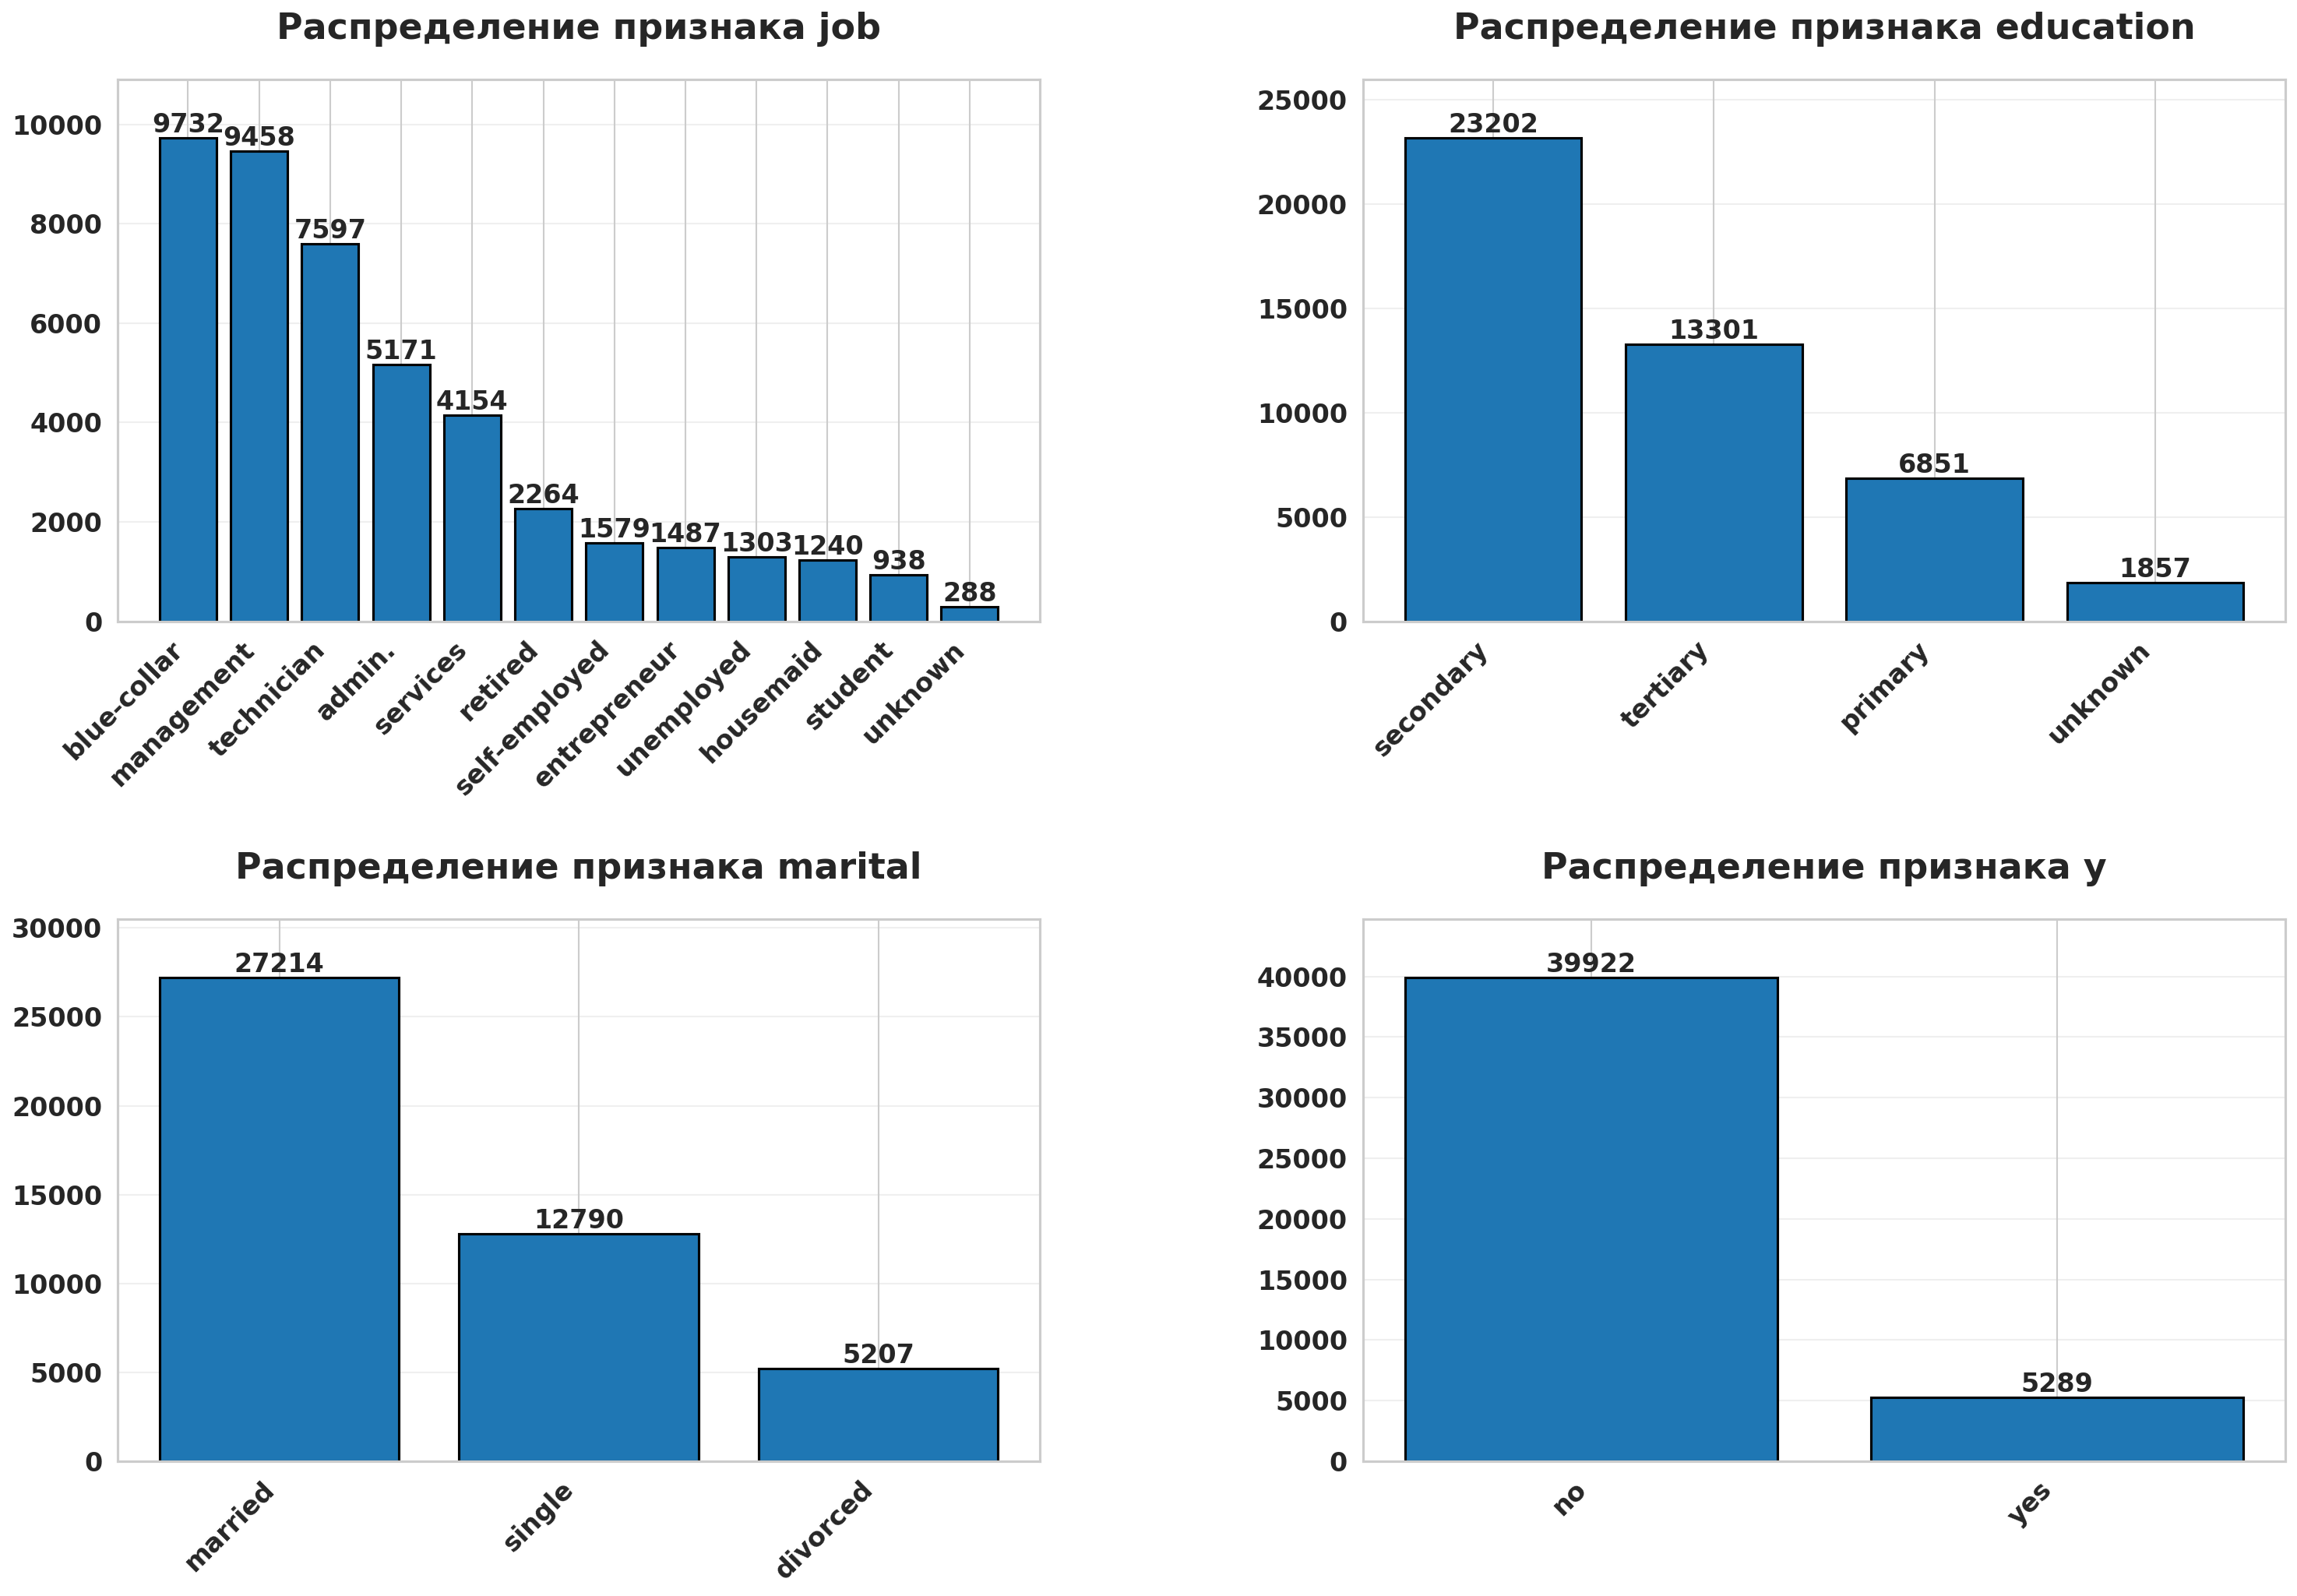

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# === ГЛОБАЛЬНЫЕ НАСТРОЙКИ: ВСЁ КРУПНОЕ ===
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 22,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'font.weight': 'bold',
    'figure.dpi': 150
})

cat_cols = ['job', 'education', 'marital', 'y']

# Большой холст, чтобы крупный текст помещался без наложений
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()

    # Рисуем столбцы
    bars = axes[i].bar(counts.index, counts.values, color='#1f77b4', edgecolor='black', linewidth=1.5)

    # === КРУПНЫЕ ЗНАЧЕНИЯ НАД СТОЛБИКАМИ ===
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}',
                     ha='center', va='bottom', fontsize=16, fontweight='bold')

    # Заголовки графиков (очень крупные)
    axes[i].set_title(f'Распределение признака {col}', fontsize=22, fontweight='bold', pad=25)

    # Подписи категорий (повернуты, чтобы не слипались)
    axes[i].tick_params(axis='x', rotation=45, labelsize=16)
    for label in axes[i].get_xticklabels():
        label.set_ha('right')

    axes[i].grid(axis='y', alpha=0.3)
    axes[i].set_axisbelow(True)
    axes[i].margins(y=0.12)  # Отступ сверху, чтобы цифры не прилипали к заголовку

# Настройка расстояний между графиками
plt.tight_layout()
plt.subplots_adjust(hspace=0.55, wspace=0.35)

# Сохранение в высоком качестве
plt.savefig('figure_8_big_font.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()



###1.3.3 - 1.3.5 Преобразование и создание признаков

In [13]:
import pandas as pd

# --- 1.3.4 Агрегация редких значений (Сначала чистим редкие категории) ---
print(" 1.3.4 Замена редких 'unknown' на 'other'...")
cols_to_clean = ['job', 'education', 'marital', 'contact', 'poutcome'] # Примерный список
for col in cols_to_clean:
    if col in df.columns:
        # Если в столбце есть 'unknown', меняем на 'other'
        if 'unknown' in df[col].values:
            df[col] = df[col].replace('unknown', 'other')

print(f" Готово. Пример значений в 'job' после очистки: {df['job'].unique()}")


# --- 1.3.3 One-Hot Encoding (Переводим текст в 0 и 1) ---
print("\n 1.3.3 Применение One-Hot Encoding...")
# Создаем список столбцов для кодирования (все категориальные, кроме таргета 'y')
cat_cols = ['job', 'marital', 'education', 'month', 'contact', 'poutcome']

# Преобразуем их в бинарный вид (0/1)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

print(f" Готово. Добавлено новых числовых столбцов. Размер датафрейма: {df_encoded.shape}")
# --- 1.3.5 Создание признака финансовой нагрузки ---
print("\n 1.3.5 Создание признака 'financial_commitment'...")
# Давайте сделаем это безопасно:
df_encoded['housing_num'] = (df_encoded['housing'] == 'yes').astype(int)
df_encoded['loan_num'] = (df_encoded['loan'] == 'yes').astype(int)

# Суммируем
df_encoded['financial_commitment'] = df_encoded['housing_num'] + df_encoded['loan_num']
print(f" Готово. Распределение нагрузки:\n{df_encoded['financial_commitment'].value_counts()}")

 1.3.4 Замена редких 'unknown' на 'other'...
 Готово. Пример значений в 'job' после очистки: ['management' 'technician' 'entrepreneur' 'blue-collar' 'other' 'retired'
 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid' 'student']

 1.3.3 Применение One-Hot Encoding...
 Готово. Добавлено новых числовых столбцов. Размер датафрейма: (45211, 48)

 1.3.5 Создание признака 'financial_commitment'...
 Готово. Распределение нагрузки:
financial_commitment
1    23640
0    17204
2     4367
Name: count, dtype: int64
